# TensorLens Demo

This notebook demonstrates how to compute and visualize relevance scores using TensorLens , for text/images.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/TensorLens')
from common.tensorlens import TensorLens

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [2]:
#these are the currently supported model families, start by testing on the smaller variants
ALL_MODELS=[
            #language models
            "facebook/opt-125m",
            "EleutherAI/pythia-70m",
            "microsoft/Phi-1.5",
            "meta-llama/Llama-3.2-1B",

            #encoder models
            "textattack/bert-base-uncased-imdb",
            "textattack/roberta-base-imdb",

            #vision transformer
            "facebook/deit-tiny-patch16-224",
            ]

In [3]:
import sys
print(sys.executable)
!pip install Pillow matplotlib
!pip install transformers==4.40.0


/usr/bin/python3


In [4]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

# Reload modules to pick up any changes
import importlib
from common import plotutils
importlib.reload(plotutils)

from common.tensorlens import TensorLens, TENSOR_RELEVANCE_METHODS
from common.baseline_methods import BaselineMethods, BASELINE_RELEVANCE_METHODS
from common.plotutils import create_summary_figure, plot_text_relevance_colored
import requests


## Configuration


In [5]:
# Choose model and input type
MODEL_PATH = "facebook/deit-tiny-patch16-224"  # Image model

#For image models
IMAGE_PATH="example_images/catdog.png"

# For text models
# TEXT = "The movie was really great"
TEXT = "The movie was not bad"


# Device and dtype
DEVICE = "cuda:0"
DTYPE = torch.float32

# Check if image model
IS_IMAGE = any(x in MODEL_PATH.lower() for x in ["deit", "vit"])
print(f"Model: {MODEL_PATH}")
print(f"Type: {'Image' if IS_IMAGE else 'Text'}")
print(f"Image: {IMAGE_PATH}")
print(f"Device: {DEVICE}")


Model: facebook/deit-tiny-patch16-224
Type: Image
Image: example_images/catdog.png
Device: cuda:0


## Load Model


In [6]:
# Load model (BaselineMethods includes both tensor and baseline methods)
# lens = BaselineMethods(model_path=MODEL_PATH, device=DEVICE, dtype=DTYPE)
tensorlens = TensorLens(model_path=MODEL_PATH, device=DEVICE, dtype=DTYPE)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transforme

pytorch_model.bin:   0%|          | 0.00/23.0M [00:00<?, ?B/s]

Error loading deit model from facebook/deit-tiny-patch16-224


NameError: name 'exit' is not defined

## Prepare Input


In [ ]:
if IS_IMAGE:
    if IMAGE_PATH.startswith("http"):
        response = requests.get(IMAGE_PATH, stream=True)
        image = Image.open(response.raw).convert("RGB")
    else:
        image = Image.open(IMAGE_PATH).convert("RGB")
    input_ids = tensorlens.feature_extractor(image, return_tensors="pt")['pixel_values'].to(DEVICE).to(DTYPE)
    input_data = image
    print(f"Image: {IMAGE_PATH}")
    print(f"Input shape: {input_ids.shape}")

else:
    # Tokenize text
    input_ids = tensorlens.tokenizer.encode(TEXT, return_tensors="pt").to(DEVICE)
    tokens = [tensorlens.tokenizer.decode([t]) for t in input_ids[0].tolist()]
    input_data = tokens
    print(f"Text: '{TEXT}'")
    print(f"Tokens ({len(tokens)}): {tokens}")


Image: example_images/catdog.png
Input shape: torch.Size([1, 3, 224, 224])


## Calculating the Tensor
The following are two methods of calculting the tensor from our paper.

We wrap the original model using hooks to fix the attention maps, mlp activations, and layernorm statistics to freeze them to those of the input we want to use.
1. calculates the full $[L,D,L,D]$ tensor, using $L\cdot D$ forward passes on the wrapped model, where the inputs are unit vectors (possibly batched)
2. calculates the $[D,L,D]$ slice of the tensor relative to a specific output position, using the jacobian of the wrapped model.

We validate correctness by applyng the function induced by the tensor on the input embeds, comparing it to the original last hidden state.

According to Eq.19 of the paper, we should have:

$\forall i \in [L]: \mathcal{F}\left(X\right)_{\left[ i,:\right]}=\sum_{j}\underset{D\times D}{\underbrace{\mathcal{T}_{\left[i,:,j,:\right]}^{}}}\underset{D}{\underbrace{X_{\left[ j,:\right]}^{\top}}}\,+B.$


In [ ]:
#method 1: full tensor:
#this might be gpu-ram heavy- check it only on small models
T,B=tensorlens.compute_full_tensor_in_forward_mode(input_ids,batch_size=1000,full_device=DEVICE)
#T.shape=(L,D,L,D), B.shape=(L,D)


#method 2: tensor slice with jacobian:
out_pos=-1 #the output position to compute the tensor slice for, -1 for language models, 0 for encoders with cls token
jacobian,_,_=tensorlens.compute_tensor_for_single_out_pos_with_jacobian(input_ids,out_pos=out_pos)
#jacobian.shape=(D,L,D), input_embeds.shape=(1,L,D), outputs.shape=(1,L,D)
del T,B,jacobian


#test difference between tensor forward pass and last hidden state:
tensorlens.test_tensor_forwardpass_correctness(input_ids)


del tensorlens

Batched full matrix: 100%|██████████| 38/38 [00:17<00:00,  2.23it/s]

max abs diff jacobian and T: 7.152557373046875e-07
max abs diff last hidden state and tensor last hidden state: 1.9371509552001953e-05
max abs diff logits and tensor logits: 4.76837158203125e-06


# Computing Relevance scores with TensorLens

Following section 3.5 of the paper, the $[L,D,L,D]$ tensor can be collapsed to an $[L,L]$ which corresponds to how much each input token influences each output token.

If we are intersted only in the influence on the last token (or cls token), we can use the more efficient jacobian method to compute only a $[D,L,D]$ slice of the tensor,

and collapse it to a length $[L]$ relevance vector in the following ways:

1. Eq. 20: Norm based    $\forall i\in[L]:T_{out\leftarrow i}^{\text{Norm}}=\left\Vert \mathcal{T}_{\left[out,:,i,:\right]}\right\Vert _{2}$

2. Eq. 21: Using inner product with first+last hidden states: $\forall i\in[L]:T_{out\leftarrow i}^{\text{IO}}=X_{\left[out,:\right]}^{N}\mathcal{T}_{\left[out,:,i,:\right]}X_{\left[i,:\right]}^{0}$

this has the property that the relevances sum up to the norm of the last hidden state (up to biases):

$\left\Vert X_{\left[out,:\right]}^{N}\right\Vert ^{2}=\sum_{i}T_{out\leftarrow i}^{\text{IO}}$

3. Eq. 23: Using inner product with first hidden state and the unembedding vector of the predicted token/class $c$: $\forall i\in\left[L\right]:T_{\left(c,out\right)\leftarrow j}^{\text{CLS}}=E_{\left[:,c\right]}^{out}\mathcal{T}_{\left[out,:,i,:\right]}X_{\left[i,:\right]}^{0}\,$

this has the property that the relevances sum up to the logit of the predicted token/class







## Get Model Prediction


In [ ]:
lens=BaselineMethods(model_path=MODEL_PATH, device=DEVICE, dtype=DTYPE)
with torch.no_grad():
    outputs = lens.model(input_ids, output_attentions=True, output_hidden_states=True)

logits = outputs.logits

if IS_IMAGE:
    predicted_class = logits.argmax(-1).item()
    confidence = torch.softmax(logits, dim=-1).max().item()
    class_label = lens.model.config.id2label.get(predicted_class, str(predicted_class))
    prediction_info = f"Predicted: {class_label} (confidence: {confidence:.2%})"
elif "bert" in MODEL_PATH:
    #get sentiment
    predicted_class = logits.argmax(-1).item()
    confidence = torch.softmax(logits, dim=-1).max().item()
    class_label = "positive" if predicted_class == 1 else "negative"
    prediction_info = f"Predicted: {class_label} (confidence: {confidence:.2%})"
else:
    out_pos = lens.model_config.out_pos
    next_token_logits = logits[0, out_pos, :] if logits.dim() == 3 else logits[0, :]
    predicted_class = next_token_logits.argmax(-1).item()
    top_probs, top_indices = torch.softmax(next_token_logits, dim=-1).topk(5)
    top_tokens = [lens.tokenizer.decode([idx]) for idx in top_indices.tolist()]
    prediction_info = f"Predicted: '{lens.tokenizer.decode([predicted_class])}'"

print(prediction_info)
print(f"Using class_id={predicted_class} for tensor_input+class")


Predicted: tiger cat (confidence: 12.49%)
Using class_id=282 for tensor_input+class


In [ ]:
# predicted_class = logits.argmax(-1).item()
# #topk
# top_5_classes = torch.argsort(logits, dim=-1, descending=True)[0, :20]
# top_5_probs = torch.softmax(logits, dim=-1)[0, top_5_classes].cpu().numpy()
# top_5_tokens = [lens.model.config.id2label.get(idx, str(idx)) for idx in top_5_classes.tolist()]
# for token, prob, class_id in zip(top_5_tokens, top_5_probs, top_5_classes):
#     print(f"{token}: {prob:.2%},class_id={class_id}")
# # predicted_class=677
# predicted_class=232

## Compute Relevance Scores


In [ ]:
# Compute tensor-based relevance
# Compute Jacobian (for tensor methods)
out_pos = lens.model_config.out_pos

print("Computing Jacobian...")
jacobian, input_embeds, outputs = lens.compute_tensor_for_single_out_pos_with_jacobian(input_ids)
print(f"Jacobian shape: {jacobian.shape}")

tensor_relevances = {}
print("Tensor methods:")
for method in TENSOR_RELEVANCE_METHODS:
    try:
        rel = TensorLens.compute_relevance(
            lens, method=method, input_ids=input_ids, out_pos=out_pos,
            class_id=predicted_class, jacobian=jacobian,
            input_embeds=input_embeds, outputs=outputs
        )
        tensor_relevances[method] = rel
        print(f"  {method}: {rel.shape}")
    except Exception as e:
        print(f"  {method}: Error - {e}")


Computing Jacobian...
Jacobian shape: torch.Size([192, 197, 192])
Tensor methods:
  tensor_norm: (196,)
  tensor_input+norm: (196,)
  tensor_input+output: (196,)
  tensor_input+class: (196,)


### Baseline methods

For the baseline methods we use attention rollout, mean attention over layers, and extenstions of these methods to incorprate contributions of the residual and layernorms,

as presented in these papers:

- "Attention is Not Only a Weight: Analyzing Transformers with Vector Norms"
Goro    Kobayashi, Tatsuki Kuribayashi, Sho Yokoi, Kentaro Inui
https://arxiv.org/abs/2004.10102

- "Incorporating Residual and Normalization Layers into Analysis of Masked Language Models"
Goro Kobayashi, Tatsuki Kuribayashi, Sho Yokoi, Kentaro Inui
https://arxiv.org/abs/2109.07152


- "GlobEnc: Quantifying Global Token Attribution by Incorporating the Whole Encoder Layer in Transformers"
Ali Modarressi, Mohsen Fayyaz, Yadollah Yaghoobzadeh, Mohammad Taher Pilehvar
https://aclanthology.org/2022.naacl-main.19/


In [ ]:
# Compute baseline relevance
baseline_relevances = {}
print("Baseline methods:")
for method in BASELINE_RELEVANCE_METHODS:
    try:
        rel = lens.compute_relevance(method=method, input_ids=input_ids)
        baseline_relevances[method] = rel
        print(f"  {method}: {rel.shape}")
    except Exception as e:
        print(f"  {method}: Error - {e}")


Baseline methods:
  attn_rollout: (196,)
  attn_mean: (196,)
  weighted_attn_rollout: (196,)
  weighted_attn_mean: (196,)
  weighted_attn_res_LN_rollout: (196,)
  weighted_attn_res_LN_mean: (196,)
  global_enc_mean: (196,)
  global_enc_rollout: (196,)


## Visualize Results


In [ ]:
# Combine all relevance scores
all_relevances = {}
for method, rel in tensor_relevances.items():
    if rel is not None:
        all_relevances[f"[T] {method}"] = rel
for method, rel in baseline_relevances.items():
    if rel is not None:
        all_relevances[f"[B] {method}"] = rel

print(f"Total methods: {len(all_relevances)}")


Total methods: 12


/home/idoatad/TensorLens/common/plotutils.py:657: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave room for colorbar at top


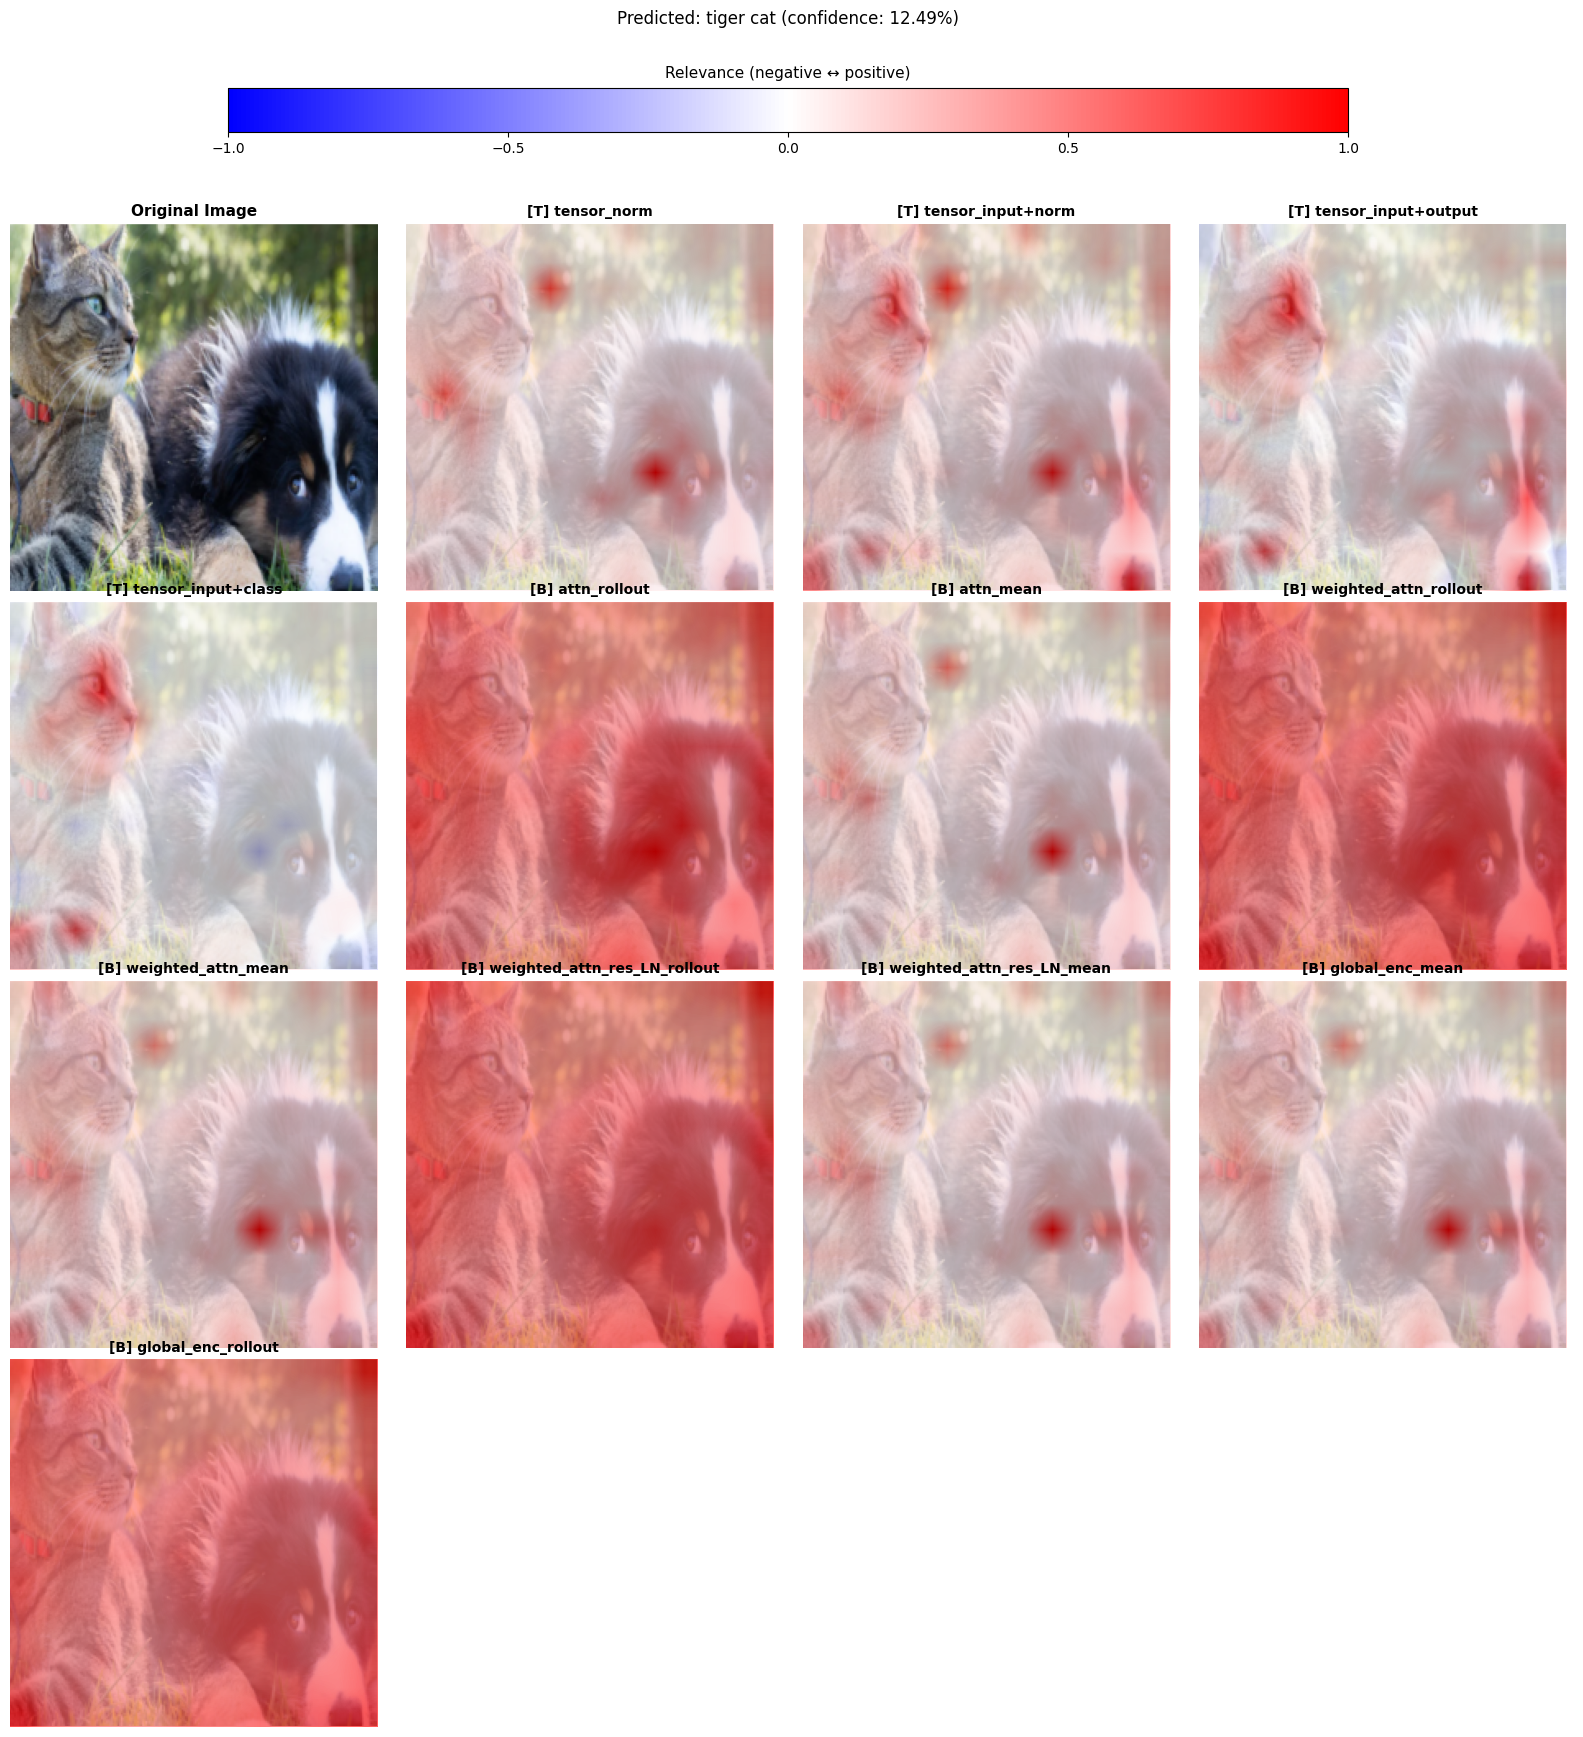

In [ ]:
# Create visualization
# Use "signed" normalization to show negative relevance with diverging colormap
# bwr: Vivid Blue = negative, White = zero, Vivid Red = positive

if IS_IMAGE:
    fig = create_summary_figure(
        input_data=input_data,
        relevance_dict=all_relevances,
        is_image=IS_IMAGE,
        prediction_info=prediction_info,
        cmap="bwr",              # Vivid blue-white-red colormap
        normalize="signed",      # Normalize to [-1, 1] to show negative relevance
        save_path="demo_outputs/notebook_output.png"
    )
else:
    # For text: use colored highlighted text visualization
    fig = plot_text_relevance_colored(
        tokens=input_data if "bert" not in MODEL_PATH.lower() else input_data[1:],
        relevance_dict=all_relevances,
        cmap="bwr",              # Vivid blue-white-red colormap
        normalize="signed",      # Normalize to [-1, 1] to show negative relevance
        save_path="demo_outputs/notebook_output.png"
    )
plt.show()
